## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [127]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
# ! pip install ucimlrepo
!pip install ucimlrepo

In [128]:
# Data
from ucimlrepo import fetch_ucirepo

# Predictor features and target variable
forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [129]:
# Loading the data
import pandas as pd
df = pd.read_csv("forestfires.csv")
# Structure

print(df.head())
print(df.info())
print(df.shape)

   X  Y month  day  FFMC   DMC     DC  ISI  temp  RH  wind  rain  area
0  7  5   mar  fri  86.2  26.2   94.3  5.1   8.2  51   6.7   0.0   0.0
1  7  4   oct  tue  90.6  35.4  669.1  6.7  18.0  33   0.9   0.0   0.0
2  7  4   oct  sat  90.6  43.7  686.9  6.7  14.6  33   1.3   0.0   0.0
3  8  6   mar  fri  91.7  33.3   77.5  9.0   8.3  97   4.0   0.2   0.0
4  8  6   mar  sun  89.3  51.3  102.2  9.6  11.4  99   1.8   0.0   0.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null

### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt


In [131]:
# Summary statistics
print(df.describe())

                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192    4.559477   
min      1.000000    2.000000   18.700000    1.100000    7.900000    0.000000   
25%      3.000000    4.000000   90.200000   68.600000  437.700000    6.500000   
50%      4.000000    4.000000   91.600000  108.300000  664.200000    8.400000   
75%      7.000000    5.000000   92.900000  142.400000  713.900000   10.800000   
max      9.000000    9.000000   96.200000  291.300000  860.600000   56.100000   

             temp          RH        wind        rain         area  
count  517.000000  517.000000  517.000000  517.000000   517.000000  
mean    18.889168   44.288201    4.017602    0.021663    12.847292  
std      5.806625   16.317469    1.791653    0.295959    63.655

In [132]:
# Missind values
print(df.isnull().sum())

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64


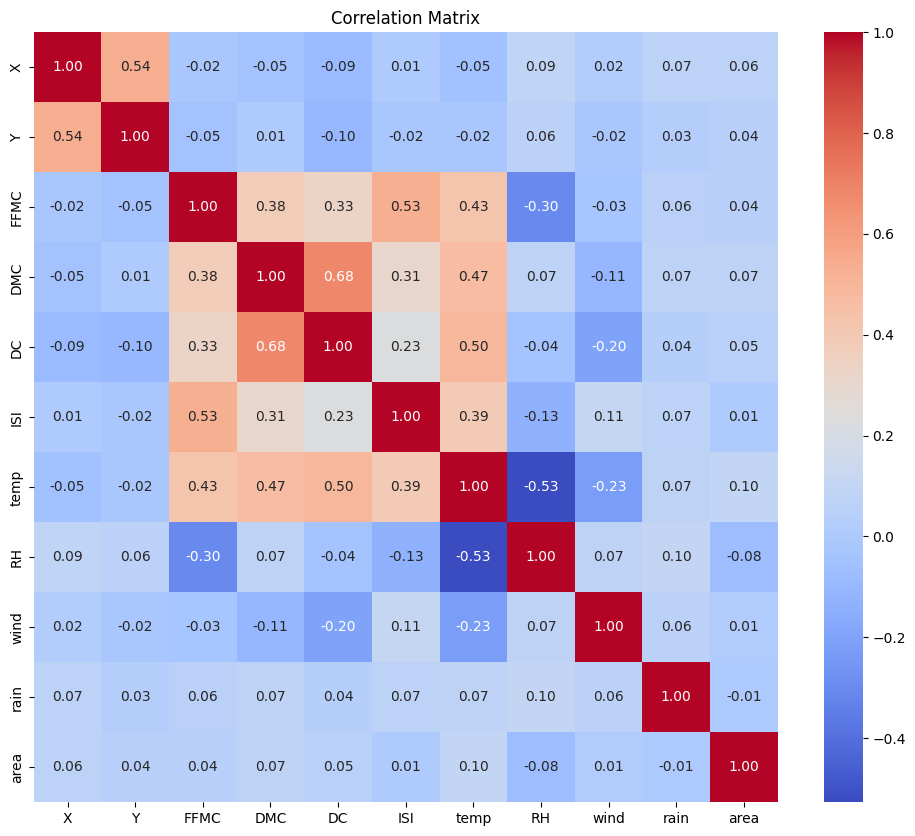

In [133]:
# Correlation matrix
plt.figure(figsize=(12,10))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

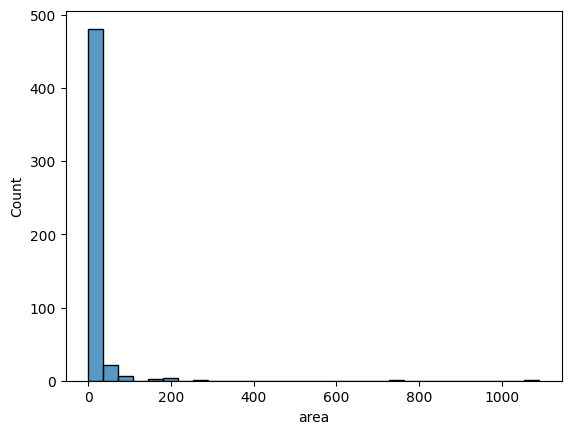

In [134]:
# Histoplot of the target variable
sns.histplot(df['area'], bins=30)
plt.show()

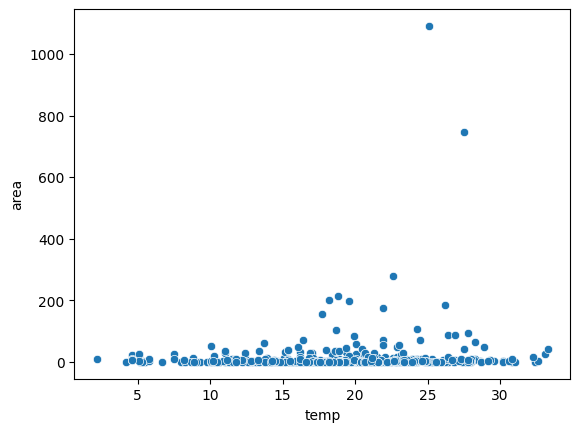

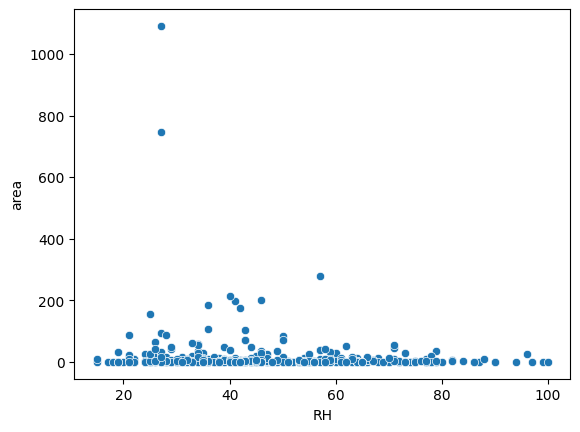

In [135]:
# Scatter plot of area vs temp and area vs RH
sns.scatterplot(x='temp', y='area', data=df)
plt.show()

sns.scatterplot(x='RH', y='area', data=df)
plt.show()

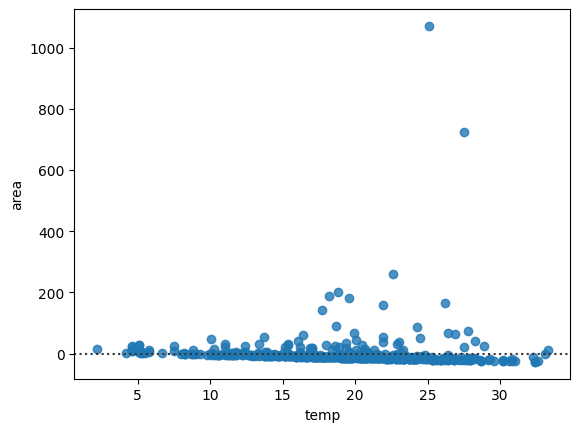

In [136]:
# Residual plot of area vs temp
sns.residplot(x=df['temp'], y=df['area'])
plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [137]:
# Defining the features and target variable
import statsmodels.api as sm

X = df[['temp', 'RH', 'wind', 'FFMC', 'DMC', 'DC', 'ISI']]
y = np.log1p(df['area'])  # log transform

X_const = sm.add_constant(X)

In [138]:
# Building the baseline model
model1 = sm.OLS(y, X_const).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.445
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.185
Time:                        11:59:01   Log-Likelihood:                -901.38
No. Observations:                 517   AIC:                             1819.
Df Residuals:                     509   BIC:                             1853.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1547      1.351      0.114      0.9

In [139]:
# Quadratic terms
df['temp_sq'] = df['temp']**2
df['DMC_sq'] = df['DMC']**2

In [140]:
X2 = df[['temp', 'temp_sq', 'DMC', 'DMC_sq', 'RH', 'wind', 'ISI']]
X2_const = sm.add_constant(X2)

model2 = sm.OLS(y, X2_const).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     2.791
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00739
Time:                        11:59:02   Log-Likelihood:                -896.73
No. Observations:                 517   AIC:                             1809.
Df Residuals:                     509   BIC:                             1843.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0708      0.594      3.487      0.0

In [141]:
# Interractive terms
df['temp_DMC'] = df['temp'] * df['DMC']
df['temp_RH'] = df['temp'] * df['RH']
df['temp_wind'] = df['temp'] * df['wind']
df['DMC_ISI'] = df['DMC'] * df['ISI']

X3 = df[['temp', 'DMC', 'temp_DMC', 'RH', 'temp_RH', 'temp_wind', 'DMC_ISI']]

In [142]:
X3 = df[['temp', 'DMC', 'temp_DMC', 'RH', 'temp_RH', 'temp_wind', 'DMC_ISI']]
X3_const = sm.add_constant(X3)

model3 = sm.OLS(y, X3_const).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.520
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.158
Time:                        11:59:02   Log-Likelihood:                -901.12
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     509   BIC:                             1852.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7137      0.649      2.642      0.0

In [143]:
# Log-transforming the target variable for improvement
import numpy as np

df['log_area'] = np.log1p(df['area'])
df['log_area']
X = df[['FFMC','DMC','DC','ISI',
        'temp','RH','wind','rain']] 
y = df['log_area']

X_const = sm.add_constant(X)
model2 = sm.OLS(y, X_const).fit()
print(model2.summary())


                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.288
Date:                Mon, 08 Jun 2026   Prob (F-statistic):              0.247
Time:                        11:59:02   Log-Likelihood:                -901.28
No. Observations:                 517   AIC:                             1821.
Df Residuals:                     508   BIC:                             1859.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2224      1.360      0.163      0.8

Model2 imroved form model1 as the adujsted r2 increased from 0.001 to 0.004 indictaing that the model is no focused on noises.

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [144]:
# Model comparison
comparison = pd.DataFrame({
    "Model": ["Baseline", "Quadratic", "Interaction"],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R2": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

comparison

,Model,R2,Adj_R2,AIC,BIC
0,Baseline,0.019482,0.005997,1818.766418,1852.750761
1,Quadratic,0.019881,0.004446,1820.555830,1858.788216
2,Interaction,0.020469,0.006998,1818.245599,1852.229942


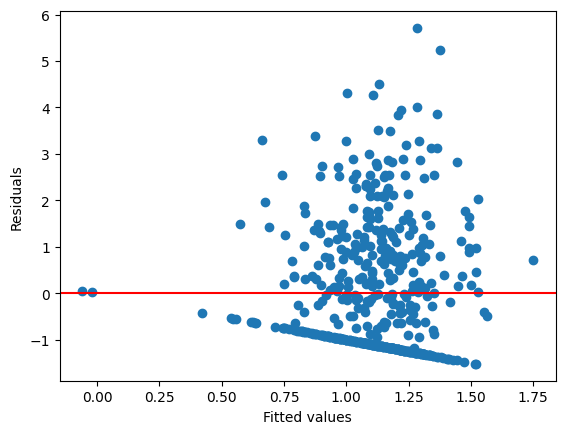

In [145]:
# Ploting residuals for the best model (model2)
import matplotlib.pyplot as plt

plt.scatter(model2.fittedvalues, model2.resid)
plt.axhline(y=0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

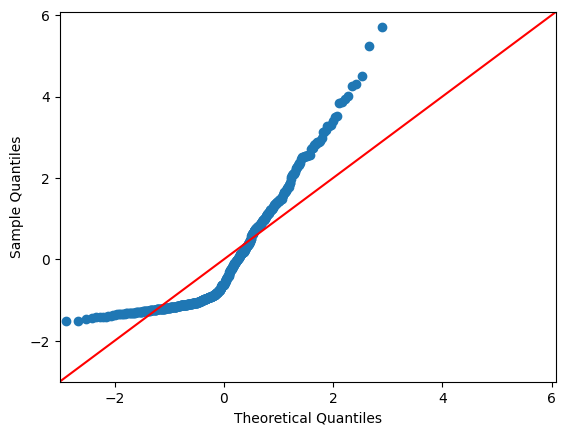

In [146]:
# Q-Q plot for normality of residuals
import statsmodels.api as sm

sm.qqplot(model2.resid, line='45')
plt.show()

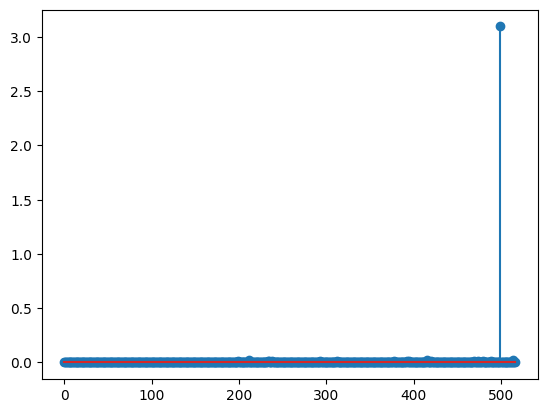

In [147]:
# Identifying influential points using Cook's distance
influence = model2.get_influence()
cooks = influence.cooks_distance[0]

plt.stem(cooks)
plt.show()


### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [148]:
# Importing Ridge and Lasso regression for regularization
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler

In [149]:
# Performing scaling for regularization
X_reg = df[['temp','RH','wind','FFMC','DMC','DC','ISI']]
y_reg = np.log1p(df['area'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

In [150]:
# Ridge regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y_reg)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [151]:
# Lasso regression
lasso = Lasso(alpha=0.01)
lasso.fit(X_scaled, y_reg)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [152]:
print("Ridge_Coeff:", ridge.coef_)
print("Lasso_Coeff:", lasso.coef_)

Ridge_Coeff: [ 0.02074703 -0.07754602  0.13772871  0.04422267  0.07531815  0.06627424
 -0.1091004 ]
Lasso_Coeff: [ 0.01093688 -0.072238    0.12030378  0.02933579  0.0687433   0.06107335
 -0.08176368]


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [153]:
# Creating a binary target variable based on the median
median = df['area'].median()
df['area_binary'] = (df['area'] > median).astype(int)

In [154]:
# Logistic regression with the binary target variable
X = df[['temp','RH','wind','FFMC','DMC','DC','ISI']]
y = df['area_binary']

In [155]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [156]:
# Scaling for logistic regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [157]:
print(X_scaled.shape)
print(y_train.shape)

(517, 7)
(413,)


### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [158]:
# Logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [159]:
# Coefficients of the logistic regression model
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coef

,Feature,Coefficient
0,temp,-0.019842
1,RH,-0.087052
2,wind,0.138163
3,FFMC,0.176958
4,DMC,0.044713
5,DC,0.122643
6,ISI,-0.181830


In [160]:
# Predicted probabilities for the test set
y_prob = log_model.predict_proba(X_test_scaled)
y_prob[:5]

array([[0.54103856, 0.45896144],
       [0.4679998 , 0.5320002 ],
       [0.47914104, 0.52085896],
       [0.5974189 , 0.4025811 ],
       [0.52174695, 0.47825305]])

In [161]:
# Predicted classes for the test set
y_pred = log_model.predict(X_test_scaled)

In [162]:
# Evaluating the model using accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.4807692307692308

In [163]:
# Evaluating the model using confusion matrix
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[21, 31],
       [23, 29]])

In [164]:
# Evaluating the model using precision, recall, and F1-score
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)

0.5178571428571429

### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [165]:
# Checking for multicollinearity using Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [166]:
# VIF calculation for the features used in the logistic regression model
X_vif = df[['FFMC','DMC','DC','ISI','temp','RH','wind']]

vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [variance_inflation_factor(X_vif.values, i)
              for i in range(X_vif.shape[1])]

vif

,Variable,VIF
0,FFMC,53.187708
1,DMC,8.522537
2,DC,12.212018
3,ISI,6.399114
4,temp,27.775962
5,RH,11.540772
6,wind,6.608911


### Comparing the Models

In [167]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Quadratic", "Interaction"],
    "R2": [model1.rsquared, model2.rsquared, model3.rsquared],
    "Adj_R2": [model1.rsquared_adj, model2.rsquared_adj, model3.rsquared_adj],
    "AIC": [model1.aic, model2.aic, model3.aic],
    "BIC": [model1.bic, model2.bic, model3.bic]
})

comparison.sort_values(by="Adj_R2", ascending=False)

,Model,R2,Adj_R2,AIC,BIC
2,Interaction,0.020469,0.006998,1818.245599,1852.229942
0,Baseline,0.019482,0.005997,1818.766418,1852.750761
1,Quadratic,0.019881,0.004446,1820.555830,1858.788216


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]


 1. Using different models to determine the best fit model to predict, Adjusted R2's and AIC and BIC come to mind.
 To do this, I used interactive terms (checking how different predictors have influenve on one another).
 Interactive and qudractive model gave a higher Adjusted R2 meaning that they explain the variation in dependent variable well while accounting for the number of predictors (interactive terms) used.


2. Trade-off governs how a model generalizes to the new data by balancing between model simplicity and performance.
Simpler models like the baseline, was simle to interepret and explain since they had fewer variables while quadratic (best) performed statisticall signifficant even with many variables because by using the regularization techniques like lasso it helped the model not to learn from noises.


3. Judging form the different models comparison, interactive model performs better overall as it captures nonlinear relationships between environmental variables and fire size, shows higher Adjusted R² and lower AIC/BIC compared to the other models and it is better in presenting the complexity of fire spread dynamics.
Since fire outbreaks is influenced by combinations of weather conditions rather than single variables, making interaction-based regression more realistic.


4. This project analyzed historical wildfire data to understand the environmental conditions influencing fire severity and to develop predictive models for wildfire risk. Regression analysis showed that wildfire behavior is nonlinear and influenced by interactions between weather variables. Logistic regression provided a practical classification tool for identifying high-risk fires. Model diagnostics revealed challenges such as skewed distributions, multicollinearity, and influential extreme events. However, regularization and feature engineering improved model stability. Overall, the results demonstrate that temperature, humidity, and fire weather indices are key drivers of wildfire risk, and predictive modeling can support early warning systems and resource allocation strategies.